Python code implementing feedforward neural network models using variables derived from VECM and VAR specifications.

These scripts replicate the results reported in Table 8, Table 10, and Figure 5 of "Real Exchange Rate Dynamics and External Balances:Econometric and Artificial Neural Network Analyses" by Hironobu Nakagawa and Hongyi Chen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

In [2]:
# Load and subset data
rawdata = pd.read_excel('DataRERExtBal.xlsx',sheet_name='Data')
rawdata1 = rawdata[['Unnamed: 0','RER','nfa_GDP','GDP','CA']]
df1 = rawdata1[0:200]
#df1

In [3]:
# lag specification (default is 1, also try 2 as a robustness check)
nlag = 1
# training sample: 1970Q1-2015Q4
trnstart,trnend = 1+nlag,183
# Sample split, later for forecasting
# forecast (test) sample: 2016Q1-2019Q4
teststart,testend = 183,199

In [4]:
# Rename variables
df1 = df1.rename(columns={
    'Unnamed: 0': 'YrQrt',
    'RER': 'rer',
    'nfa_GDP': 'nfa'
})
#df1.head()

In [5]:
#df1.info()

In [6]:
# ---------------------------------------------------------
# Transformations
# ---------------------------------------------------------
# (Express real exchange rate series in logs)
df1['rer'] = np.log(df1['rer'] / 100)
df1['cagdp'] = df1['CA'] / df1['GDP']

# Obtain first-differenced series
for var in ['rer', 'nfa']:
    df1[f'd{var}'] = df1[var] - df1[var].shift(1)
#df1.head()

In [7]:
# ---------------------------------------------------------
# obtain lagged variables (1 and 2 lags)
# ---------------------------------------------------------
lag_vars = ['drer', 'dnfa', 'cagdp', 'rer', 'nfa']

for var in lag_vars:
    df1[f'lag{var}'] = df1[var].shift(1)
    df1[f'lag2{var}'] = df1[f'lag{var}'].shift(1)

# ---------------------------------------------------------
# Error correction term
# ---------------------------------------------------------
df1['ect'] = df1['lagrer'] - 0.444986 * df1['lagnfa'] - 0.1477
df1['lagect'] = df1['ect'].shift(1)

In [8]:
# Specify dependent (target or objective) variable: 'drer' for Table 8
y = df1['drer']          # alternative: df1['dnfa']  (for Table 10)

# Define model variable sets
# X for Model 1, X2 for Model 2, X3 for Model 3, X4 for Model 4
if nlag == 1:
    X = df1[['lagdrer','lagdnfa','ect']]
    X2 = df1[['lagdrer','lagdnfa']]
    X3 = df1[['lagdrer','lagdnfa','lagrer','lagnfa']]
    X4 = df1[['lagdrer','lagcagdp']]  
      
else:
    X = df1[['lagdrer','lagdnfa','ect']]
    X2 = df1[['lagdrer','lagdnfa','lag2drer','lag2dnfa']]
    X3 = df1[['lagdrer','lagdnfa','lagrer','lagnfa','lag2drer','lag2dnfa']]
    X4 = df1[['lagdrer','lagcagdp','lag2drer','lag2cagdp' ]]


In [9]:
train_y = y[trnstart:trnend]
train_xx = X[trnstart:trnend]
train_xx2 = X2[trnstart:trnend]
train_xx3 = X3[trnstart:trnend]
train_xx4 = X4[trnstart:trnend]

In [10]:
# Standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
# scale the data 
sc.fit(train_xx)
train_x = sc.transform(train_xx)
sc.fit(train_xx2)
train_x2 = sc.transform(train_xx2)
sc.fit(train_xx3)
train_x3 = sc.transform(train_xx3)
sc.fit(train_xx4)
train_x4 = sc.transform(train_xx4)

In [11]:
#df1.head(6)

In [12]:
#  Cross validation of NN models
# Initialize variables to store the best RMSE and corresponding hidden layers
min_rmse, min_rmse2, min_rmse3, min_rmse4 = float('inf'), float('inf'), float('inf'), float('inf')
best_hidden_layer_rmse, best_hidden_layer_rmse2 = None, None
best_hidden_layer_rmse3, best_hidden_layer_rmse4 = None, None 

# Hidden-layer configurations: 
# Single-layer networks: (2,), (3,), ..., (10,)
single_layer = [(i,) for i in range(2, 11)]
# Two-layer networks: (2,1), (2,2), ..., (10,10)
two_layer = [(i, j) for i in range(2, 11) for j in range(1, 11)]
hiddenlayer = single_layer + two_layer
# too many nodes/layers can lead to overfitting)

# Activation function and time-series CV
actfunction = "tanh"  # alternative: "logstic" (sigmoid)
tscv = TimeSeriesSplit(n_splits=4)

# Pack the four models into a dictionary
train_sets = {
    "model1": train_x,
    "model2": train_x2,
    "model3": train_x3,
    "model4": train_x4
}

print("Cross validation")
print("hdl  RMSE")
print("        model1    model2    model3    model4")

for hdl in hiddenlayer:

    # Store RMSE lists for each model
    rmse_dict = {m: [] for m in train_sets.keys()}

    # Time-series CV
    for tr_index, va_index in tscv.split(train_x):

        tr_y = train_y.values[tr_index]
        va_y = train_y.values[va_index]

        # Loop over the four models
        for name, Xmat in train_sets.items():

            tr_x = Xmat[tr_index]
            va_x = Xmat[va_index]

            # New NN instance for each model
            nnet = MLPRegressor(
                activation=actfunction,
                hidden_layer_sizes=hdl,
                random_state=1,
                solver="lbfgs"
            )

            nnet.fit(tr_x, tr_y)
            pred = nnet.predict(va_x)

            rmse = np.sqrt(mean_squared_error(pred, va_y))
            rmse_dict[name].append(rmse)

    # Average RMSE for each model
    avg1 = np.mean(rmse_dict["model1"])
    avg2 = np.mean(rmse_dict["model2"])
    avg3 = np.mean(rmse_dict["model3"])
    avg4 = np.mean(rmse_dict["model4"])

    print(f"{hdl}:    {avg1:.5f}    {avg2:.5f}    {avg3:.5f}    {avg4:.5f}")

    # Track best RMSE
    if avg1 < min_rmse:
        min_rmse = avg1
        best_hidden_layer_rmse = hdl

    if avg2 < min_rmse2:
        min_rmse2 = avg2
        best_hidden_layer_rmse2 = hdl

    if avg3 < min_rmse3:
        min_rmse3 = avg3
        best_hidden_layer_rmse3 = hdl

    if avg4 < min_rmse4:
        min_rmse4 = avg4
        best_hidden_layer_rmse4 = hdl

# Final results
print("\nMinimized RMSE Scores and Corresponding Hidden Layers:")
print(f"Model 1: {min_rmse:.5f} (Hidden Layers: {best_hidden_layer_rmse})")
print(f"Model 2: {min_rmse2:.5f} (Hidden Layers: {best_hidden_layer_rmse2})")
print(f"Model 3: {min_rmse3:.5f} (Hidden Layers: {best_hidden_layer_rmse3})")
print(f"Model 4: {min_rmse4:.5f} (Hidden Layers: {best_hidden_layer_rmse4})")

Cross validation
hdl  RMSE
        model1    model2    model3    model4
(2,):    0.02620    0.02594    0.02645    0.06105
(3,):    0.02843    0.02852    0.02687    0.03448
(4,):    0.02671    0.03141    0.03543    0.05217
(5,):    0.03624    0.03939    0.06522    0.03233
(6,):    0.02962    0.02659    0.03675    0.03195
(7,):    0.03486    0.02823    0.04197    0.03486
(8,):    0.03088    0.03477    0.07293    0.04293
(9,):    0.04055    0.03112    0.04494    0.03058
(10,):    0.02728    0.02886    0.04814    0.03491
(2, 1):    0.02749    0.02743    0.03212    0.04904
(2, 2):    0.02733    0.03232    0.02607    0.08354
(2, 3):    0.02540    0.02688    0.03327    0.06512
(2, 4):    0.02723    0.02895    0.03615    0.07584
(2, 5):    0.02595    0.02594    0.04189    0.07379
(2, 6):    0.02700    0.04121    0.03926    0.10900
(2, 7):    0.02664    0.02973    0.03110    0.03279
(2, 8):    0.02674    0.02907    0.03644    0.03580
(2, 9):    0.02850    0.03332    0.03578    0.06322
(2, 10): 

In [13]:
# (Out-of-sample) forecast 
# foecast samples:
trainf_y, testf_y = y[trnstart:trnend], y[teststart:testend]
trainf_xx, testf_xx = X[trnstart:trnend], X[teststart:testend]
trainf_xx2, testf_xx2 = X2[trnstart:trnend],X2[teststart:testend]
trainf_xx3, testf_xx3 = X3[trnstart:trnend],X3[teststart:testend]
trainf_xx4, testf_xx4 = X4[trnstart:trnend],X4[teststart:testend]

trainf_x1, testf_x1 = sc.fit_transform(trainf_xx), sc.fit_transform(testf_xx)
trainf_x2, testf_x2 = sc.fit_transform(trainf_xx2), sc.fit_transform(testf_xx2)
trainf_x3, testf_x3 = sc.fit_transform(trainf_xx3), sc.fit_transform(testf_xx3)
trainf_x4, testf_x4 = sc.fit_transform(trainf_xx4), sc.fit_transform(testf_xx4)

In [14]:
# ---------------------------------------------------------
# Forecasting for NN models
# ---------------------------------------------------------

# Pack the forecasting inputs
forecast_sets = {
    "model1": (trainf_x1, testf_x1, best_hidden_layer_rmse),
    "model2": (trainf_x2, testf_x2, best_hidden_layer_rmse2),
    "model3": (trainf_x3, testf_x3, best_hidden_layer_rmse3),
    "model4": (trainf_x4, testf_x4, best_hidden_layer_rmse4)
}

# Dictionaries to store results
forecasts = {}
msqe_dict = {}
mae_dict = {}
r2_dict = {}
sqe_dict = {}

# Loop over the four NN models
for name, (trainX, testX, hdl) in forecast_sets.items():

    nnet = MLPRegressor(
        activation=actfunction,
        hidden_layer_sizes=hdl,
        random_state=1,
        solver="lbfgs"
    )

    nnet.fit(trainX, trainf_y)
    pred = nnet.predict(testX)

    forecasts[name] = pred
    sqe_dict[name] = (testf_y - pred)**2
    msqe_dict[name] = mean_squared_error(testf_y, pred)
    mae_dict[name] = mean_absolute_error(testf_y, pred)
    r2_dict[name] = r2_score(testf_y, pred)

# ---------------------------------------------------------
# Linear models: VECM (Model 5a) and VAR (Model 6a)
# ---------------------------------------------------------

# Model 5a: VECM (X)
lrmodel = LinearRegression()
lrmodel.fit(X[trnstart:trnend], trainf_y)
pred5 = lrmodel.predict(X[teststart:testend])

forecasts["model5a"] = pred5
sqe_dict["model5a"] = (testf_y - pred5)**2
msqe_dict["model5a"] = mean_squared_error(testf_y, pred5)
mae_dict["model5a"] = mean_absolute_error(testf_y, pred5)
r2_dict["model5a"] = r2_score(testf_y, pred5)

# Model 6a: VAR (X4)
lrmodel2 = LinearRegression()
lrmodel2.fit(X4[trnstart:trnend], trainf_y)
pred6 = lrmodel2.predict(X4[teststart:testend])

forecasts["model6a"] = pred6
sqe_dict["model6a"] = (testf_y - pred6)**2
msqe_dict["model6a"] = mean_squared_error(testf_y, pred6)
mae_dict["model6a"] = mean_absolute_error(testf_y, pred6)
r2_dict["model6a"] = r2_score(testf_y, pred6)

# ---------------------------------------------------------
# Random walk model
# ---------------------------------------------------------
sqe_rw = (testf_y)**2
msqe_rw = np.mean(sqe_rw)
mae_rw = np.mean(np.abs(testf_y))
r2_rw = 1 - (msqe_rw / np.var(testf_y))

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------

print("mean sq error")
for name in ["model1","model2","model3","model4","model5a","model6a"]:
    print(f"{name}: {msqe_dict[name]:.5f}")
print(f"RWmodel: {msqe_rw:.5f}")

print("\nmean abs err")
for name in ["model1","model2","model3","model4","model5a","model6a"]:
    print(f"{name}: {mae_dict[name]:.5f}")
print(f"RWmodel: {mae_rw:.5f}")

print("\nR2")
for name in ["model1","model2","model3","model4","model5a","model6a"]:
    print(f"{name}: {r2_dict[name]:.3f}")
print(f"modelRW: {r2_rw:.3f}")

print("\nsq err")
for name in ["model1","model2","model3","model4","model5a","model6a"]:
    print(sqe_dict[name])
print(sqe_rw)

print("\nforecasts")
for name in ["model1","model2","model3","model4","model5a","model6a"]:
    print(name)
    print(pd.Series(forecasts[name], index=testf_y.index))

print("\nactual")
print(testf_y)

mean sq error
model1: 0.00035
model2: 0.00040
model3: 0.00042
model4: 0.00045
model5a: 0.00047
model6a: 0.00045
RWmodel: 0.00044

mean abs err
model1: 0.01649
model2: 0.01663
model3: 0.01818
model4: 0.01932
model5a: 0.01856
model6a: 0.01878
RWmodel: 0.01892

R2
model1: 0.192
model2: 0.084
model3: 0.028
model4: -0.040
model5a: -0.073
model6a: -0.032
modelRW: -0.023

sq err
183    0.000087
184    0.000405
185    0.000409
186    0.000002
187    0.001581
188    0.000230
189    0.000315
190    0.000577
191    0.000168
192    0.000482
193    0.000401
194    0.000051
195    0.000227
196    0.000007
197    0.000316
198    0.000347
Name: drer, dtype: float64
183    0.000005
184    0.000275
185    0.000654
186    0.000232
187    0.001829
188    0.000032
189    0.000445
190    0.000572
191    0.000401
192    0.000456
193    0.001072
194    0.000030
195    0.000001
196    0.000079
197    0.000147
198    0.000128
Name: drer, dtype: float64
183    0.000038
184    0.000153
185    0.000793
186    0.00

In [15]:
# Compute cumulative squared errors for all models
cum_sqe_dict = {name: sqe_dict[name].cumsum() 
                for name in ["model1","model2","model3","model4","model5a","model6a"]}
# Random walk separately
cum_sqerw = sqe_rw.cumsum()

Text(0.5, 1.0, 'Cumulative squared error: NN VECM vs. other NN models ')

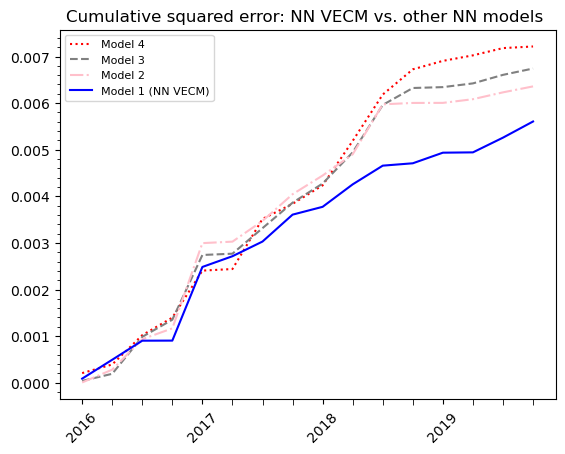

In [16]:
#  Figures
plt.plot(cum_sqe_dict["model4"],label="Model 4",color="red",linestyle="dotted")
plt.plot(cum_sqe_dict["model3"],label="Model 3",color="grey",linestyle="dashed")
plt.plot(cum_sqe_dict["model2"],label="Model 2",color="pink",linestyle="dashdot")
plt.plot(cum_sqe_dict["model1"],label="Model 1 (NN VECM)",color="blue",linestyle="solid")
#plt.plot(year[40:45],in_out_forecast2[40:45],label="NN w VAR",color="green",linestyle="dotted")
plt.legend(loc="upper left",fontsize=8)
# Mapping index values to their respective years (only at the beginning of each year)
years_mapping = {183: 2016, 187: 2017, 191: 2018, 195: 2019}  # First quarter of each year
# Positions for year labels
tick_positions = list(years_mapping.keys())
tick_labels = list(years_mapping.values())
# Setting x-axis labels for years (appearing only once per year)
plt.xticks(tick_positions, tick_labels, rotation=45)
# Enabling minor ticks to represent quarterly intervals
plt.minorticks_on()  # This ensures minor ticks appear between major ticks
plt.gca().tick_params(axis='x', which='minor', length=4)  # Small tick marks

# Labels and title
#plt.xlabel("Year")
# plt.ylabel("Value")
plt.title("Cumulative squared error: NN VECM vs. other NN models ")

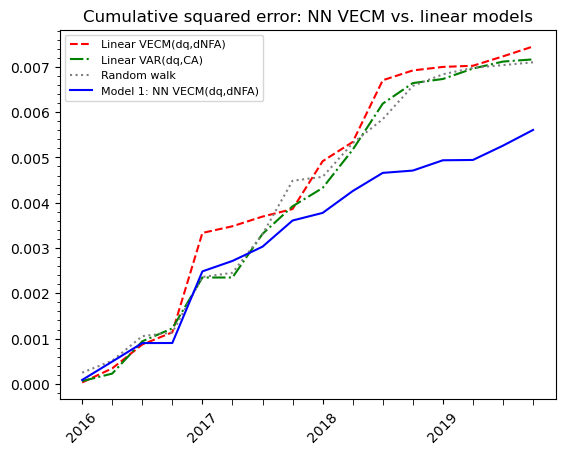

In [17]:
#lr vecm & var w/o standardization
plt.plot(cum_sqe_dict["model5a"],label="Linear VECM(dq,dNFA)",color="red",linestyle="dashed")
plt.plot(cum_sqe_dict["model6a"],label="Linear VAR(dq,CA)",color="green",linestyle="dashdot")
plt.plot(cum_sqerw,label="Random walk",color="gray",linestyle="dotted")
plt.plot(cum_sqe_dict["model1"],label="Model 1: NN VECM(dq,dNFA)",color="blue",linestyle="solid")
#plt.plot(year[40:45],in_out_forecast2[40:45],label="NN w VAR",color="green",linestyle="dotted")
plt.legend(loc="upper left",fontsize=8)

# Mapping index values to their respective years (only at the beginning of each year)
years_mapping = {183: 2016, 187: 2017, 191: 2018, 195: 2019}  # First quarter of each year
# Positions for year labels
tick_positions = list(years_mapping.keys())
tick_labels = list(years_mapping.values())
# Setting x-axis labels for years (appearing only once per year)
plt.xticks(tick_positions, tick_labels, rotation=45)
# Enabling minor ticks to represent quarterly intervals
plt.minorticks_on()  # This ensures minor ticks appear between major ticks
plt.gca().tick_params(axis='x', which='minor', length=4)  # Small tick marks

# Labels and title
#plt.xlabel("Year")
# plt.ylabel("Value")
plt.title("Cumulative squared error: NN VECM vs. linear models")

plt.show()

In [18]:
# -------------------------
# Robustness checks
#  -------------------------
# Models'in-sample performance over the ranges of NN model configurations
print('Various layers-nodes configurations')
print('hdl    MSE')
print('        model1    model2     model3     model4  ')

# Hidden-layer configurations
single_layer = [(i,) for i in range(2, 11)]
two_layer = [(i, j) for i in range(2, 11) for j in range(1, 11)]
hiddenlayer = single_layer + two_layer

actfunction = "tanh"

# Lists to store MSEs across all hdl
mse_list_1 = []
mse_list_2 = []
mse_list_3 = []
mse_list_4 = []

for hdl in hiddenlayer:
    nnet = MLPRegressor(activation=actfunction,
                        hidden_layer_sizes=hdl,
                        random_state=1,
                        solver="lbfgs")
    
    # Model 1
    nnet.fit(trainf_x1, trainf_y)
    forecast = nnet.predict(testf_x1)
    mse_a = mean_squared_error(testf_y, forecast)
    mse_list_1.append(mse_a)

    # Model 2
    nnet.fit(trainf_x2, trainf_y)
    forecast2 = nnet.predict(testf_x2)
    mse2_a = mean_squared_error(testf_y, forecast2)
    mse_list_2.append(mse2_a)

    # Model 3
    nnet.fit(trainf_x3, trainf_y)
    forecast3 = nnet.predict(testf_x3)
    mse3_a = mean_squared_error(testf_y, forecast3)
    mse_list_3.append(mse3_a)

    # Model 4
    nnet.fit(trainf_x4, trainf_y)
    forecast4 = nnet.predict(testf_x4)
    mse4_a = mean_squared_error(testf_y, forecast4)
    mse_list_4.append(mse4_a)

    print(f"{hdl}: {mse_a:.5f}    {mse2_a:.5f}    {mse3_a:.5f}    {mse4_a:.5f}")

# ---------------------------------------------------------
# Print averages across all hidden-layer configurations
# ---------------------------------------------------------

print("\nAverage MSE across all hidden-layer configurations:")
print(f"Model 1 average MSE: {np.mean(mse_list_1):.6f}")
print(f"Model 2 average MSE: {np.mean(mse_list_2):.6f}")
print(f"Model 3 average MSE: {np.mean(mse_list_3):.6f}")
print(f"Model 4 average MSE: {np.mean(mse_list_4):.6f}")

Various layers-nodes configurations
hdl    MSE
        model1    model2     model3     model4  
(2,): 0.00038    0.00040    0.00033    0.00041
(3,): 0.00035    0.00042    0.00034    0.00040
(4,): 0.00039    0.00040    0.00036    0.00041
(5,): 0.00044    0.00043    0.00034    0.00039
(6,): 0.00032    0.00042    0.00041    0.00036
(7,): 0.00039    0.00042    0.00054    0.00038
(8,): 0.00034    0.00045    0.00029    0.00043
(9,): 0.00034    0.00044    0.00038    0.00041
(10,): 0.00045    0.00048    0.00034    0.00040
(2, 1): 0.00038    0.00037    0.00034    0.00045
(2, 2): 0.00039    0.00044    0.00032    0.00040
(2, 3): 0.00035    0.00038    0.00037    0.00044
(2, 4): 0.00042    0.00043    0.00030    0.00043
(2, 5): 0.00035    0.00049    0.00030    0.00042
(2, 6): 0.00038    0.00040    0.00032    0.00048
(2, 7): 0.00040    0.00040    0.00031    0.00041
(2, 8): 0.00038    0.00047    0.00034    0.00046
(2, 9): 0.00046    0.00045    0.00034    0.00043
(2, 10): 0.00037    0.00042    0.00037 